# Fashion MNIST – Klassificering av klädesplagg

## Sammanfattning
I det här projektet har vi byggt en klassificeringsmodell som identifierar 
klädesplagg från Fashion MNIST-datasetet. Modellen tar en 28x28 gråskalebild 
som input och förutsäger vilken av 10 klasser den tillhör.

Vårt fokusområde är **optimering och learning rate**. Vi har undersökt hur 
valet av optimerare påverkar hur snabbt och stabilt modellen lär sig.

## Vad vi testade
Vi tränade samma modellarkitektur med fem olika optimerare:
- SGD (låg learning rate: 0.001)
- SGD (learning rate: 0.01)
- SGD + Momentum (learning rate: 0.01, momentum: 0.9)
- Adam (learning rate: 0.001)
- AdamW (learning rate: 0.001, weight decay: 0.01)

## Resultat
| Optimizer | Test Accuracy |
|-----------|--------------|
| Adam | 87.33% |
| AdamW | 87.25% |
| SGD + Momentum | 87.15% |
| SGD | 85.42% |
| SGD (låg lr) | 79.79% |

Adam och AdamW presterade bäst över 10 epoker, följda av SGD med momentum. 
Vi noterar dock att SGD fortfarande förbättrades vid 10 epoker och därför 
skulle kunna prestera bättre om fler epoker användes.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

## Modellarkitektur

Vi byggde ett fully connected neuralt nätverk (Dense layers) med följande struktur:

| Lager | Detaljer |
|-------|----------|
| Input | 28x28 pixlar (gråskala) |
| Flatten | Omformar bilden till en vektor av 784 värden |
| Dense | 128 neuroner, ReLU-aktivering |
| Dropout | 20% av neuroner stängs av slumpmässigt under träning |
| Dense | 10 neuroner, Softmax-aktivering (en per klass) |

### Våra val
**128 neuroner** i det dolda lagret är en balans mellan kapacitet och 
komplexitet – tillräckligt stort för att lära sig mönster i datan utan 
att bli onödigt tungt att träna.

**Dropout(0.2)** används för att minska risken för overfitting. Under 
träning stängs 20% av neuronerna av slumpmässigt, vilket tvingar nätverket 
att inte förlita sig för mycket på enskilda neuroner.

**Softmax** i outputlagret omvandlar nätverkets råa värden till 
sannolikheter för varje klass. Den klass med högst sannolikhet blir 
modellens förutsägelse.

### Dataförberedelse
Bildernas pixelvärden normaliserades från [0, 255] till [0, 1] genom 
att dividera med 255. Detta gör att träningen blir mer stabil eftersom 
nätverket hanterar små tal bättre än stora.

In [2]:
#Load dataseet

fashion_mnist = tf.keras.datasets.fashion_mnist

# Train och test uppdelning är redan hårdkodad av Zalando
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()



In [3]:
print(train_images.shape)
print(test_images.shape)

print(train_labels)


(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


In [4]:
# Klassnamn från https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
# Normalisera pixelvärden från [0, 255] till [0, 1]
train_images = train_images / 255.0

test_images = test_images / 255.0

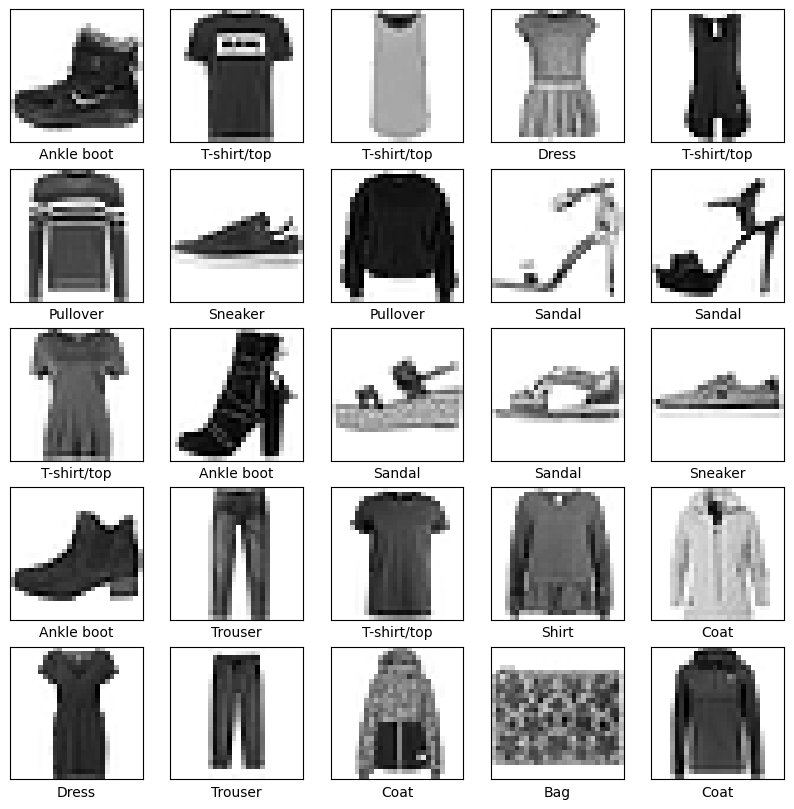

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [7]:
# Build neural network
# Keras default är batch size = 32

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),      # Valde 128 neuroner för att det är en vanlig storlek 
    Dropout(0.2),
    Dense(10, activation='softmax')     
])


In [8]:
# Compile Model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Träning och validering

Alla modeller tränades med följande inställningar:
- 10 epochs
- Batch size: 32
- Validation split: 0.2 (20% av träningsdatan används för validering)

Det innebär att modellen i praktiken tränas på 48 000 bilder och 
valideras på 12 000 bilder per epoch. De 10 000 testbilderna används 
endast för den slutliga utvärderingen.

Observation: hoppig valideringskurva
Vid träning med Adam noterade vi att valideringskurvan studsade lite 
upp och ner mellan epochs, medan träningskurvan sjönk stadigt.

Detta är normalt och beror på två saker:
- Valideringsdatan är mindre (12 000 bilder) vilket gör kurvan känsligare 
  för slumpvariationer
- Dropout är aktiv under träning men avstängd vid validering, vilket 
  introducerar lite variation från epoch till epoch

In [9]:
# Train Model

history = model.fit(
    train_images,
    train_labels,
    epochs=10,              # Istället för att välja 10 epochs så kan vi kolla vilket nummer som är optimalt
    
    validation_split=0.2
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.8036 - loss: 0.5540 - val_accuracy: 0.8386 - val_loss: 0.4394
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.8515 - loss: 0.4110 - val_accuracy: 0.8637 - val_loss: 0.3773
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.8652 - loss: 0.3730 - val_accuracy: 0.8662 - val_loss: 0.3587
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.8696 - loss: 0.3545 - val_accuracy: 0.8707 - val_loss: 0.3500
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 606us/step - accuracy: 0.8763 - loss: 0.3364 - val_accuracy: 0.8749 - val_loss: 0.3498
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.8802 - loss: 0.3219 - val_accuracy: 0.8800 - val_loss: 0.3323
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.8831 - loss: 0.3111 - val_accuracy: 0.8740 - val_loss: 0.3479
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - accuracy: 0.8882 -

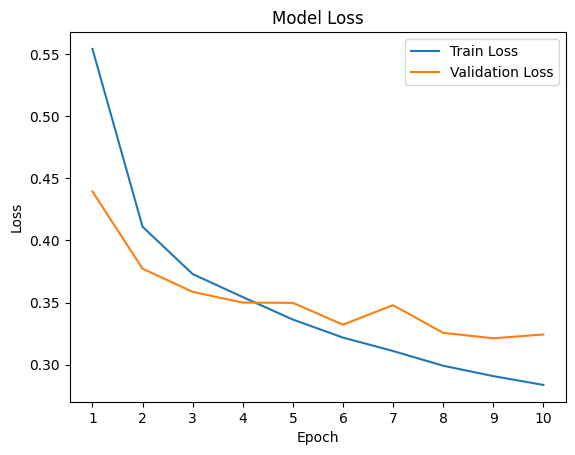

In [10]:
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'])
plt.plot(epochs, history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.xticks(epochs)

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()


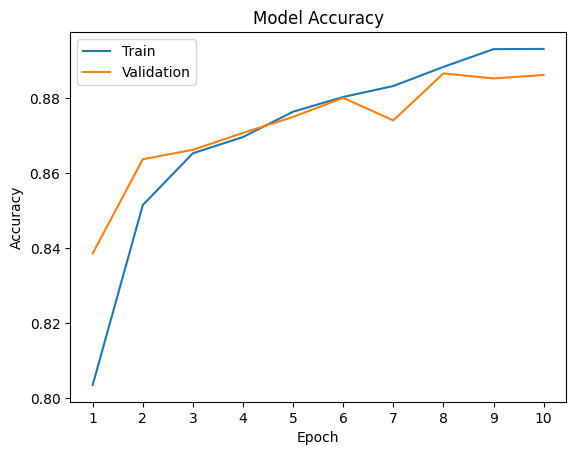

In [11]:
plt.plot(epochs, history.history['accuracy'])
plt.plot(epochs, history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(epochs)

plt.show()


In [12]:
# Validation 

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels
)

print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.8776 - loss: 0.3451
Test accuracy: 0.8776000142097473


## Overfitting och Underfitting

För att analysera modellens generaliseringsförmåga tränades Adam-modellen i 30 epochs.

I början av träningen förbättrades både tränings- och valideringsaccuracy snabbt, 
vilket tyder på att modellen fortfarande var underfittad och höll på att lära sig 
grundläggande mönster i datan.

Mellan ungefär epoch 5 och 10 låg tränings- och valideringskurvorna nära varandra, 
vilket indikerar god generalisering.

Efter cirka epoch 10 började dock tydliga tecken på overfitting synas:
- träningsaccuracy fortsatte öka
- träningsloss fortsatte minska
- valideringsaccuracy planade ut
- valideringsloss började variera och långsamt öka

Detta visar att modellen fortsatte optimera mot träningsdatan utan att förbättra 
sin prestation på ny data.

Dropout(0.2) hjälpte sannolikt till att begränsa overfitting, eftersom skillnaden 
mellan tränings- och valideringskurvorna fortfarande förblev relativt måttlig.

In [13]:
# Skapa en ny modell och optimera den, ta 30 epochs. 

model_uo = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model_uo.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_uo = model_uo.fit(
    train_images,
    train_labels,
    epochs=30,
    validation_split=0.2
)





Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 622us/step - accuracy: 0.8066 - loss: 0.5482 - val_accuracy: 0.8549 - val_loss: 0.4099
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - accuracy: 0.8518 - loss: 0.4059 - val_accuracy: 0.8685 - val_loss: 0.3749
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - accuracy: 0.8640 - loss: 0.3710 - val_accuracy: 0.8714 - val_loss: 0.3559
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.8724 - loss: 0.3487 - val_accuracy: 0.8724 - val_loss: 0.3533
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 561us/step - accuracy: 0.8768 - loss: 0.3354 - val_accuracy: 0.8741 - val_loss: 0.3482
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.8824 - loss: 0.3217 - val_accuracy: 0.8802 - val_loss: 0.3413
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step - accuracy: 0.8847 - loss: 0.3102 - val_accuracy: 0.8798 - val_loss: 0.3301
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step - accuracy: 0.8895 -

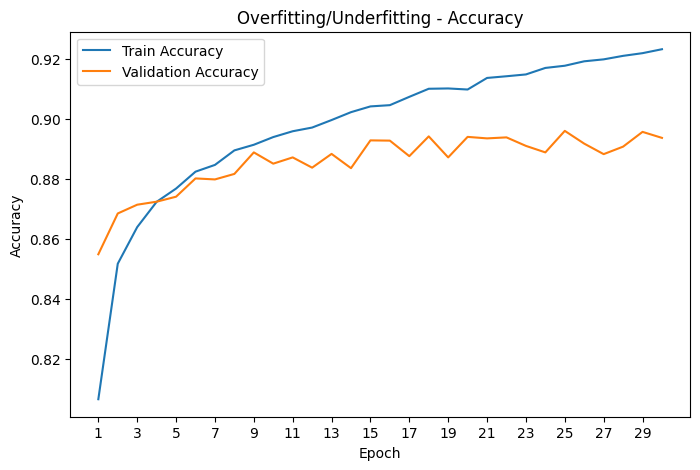

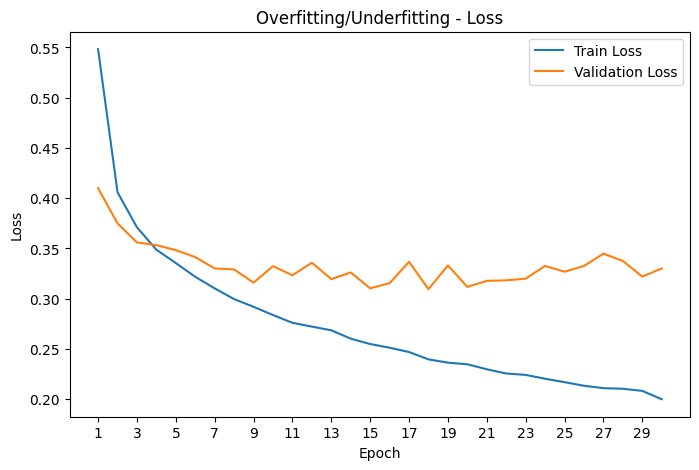

In [14]:
epochs = range(1, len(history_uo.history['loss']) + 1)

# Accuracy
plt.figure(figsize=(8,5))

plt.plot(epochs, history_uo.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history_uo.history['val_accuracy'], label='Validation Accuracy')

plt.title("Overfitting/Underfitting - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs[::2])
plt.legend()

plt.show()

# Loss
plt.figure(figsize=(8,5))

plt.plot(epochs, history_uo.history['loss'], label='Train Loss')
plt.plot(epochs, history_uo.history['val_loss'], label='Validation Loss')

plt.title("Overfitting/Underfitting - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs[::2])
plt.legend()

plt.show()

## Analys av optimerare

Vi tränade samma modell fem gånger med olika optimerare för att kunna 
göra en rättvis jämförelse. Enda skillnaden mellan körningarna var 
valet av optimerare – arkitektur, antal epochs och batch size var identiska.

### SGD – Stochastic Gradient Descent
Vanlig SGD med learning rate 0.01 startade på 71.6% accuracy vid epoch 1 
och förbättrades stadigt till 85.4% vid epoch 10. Kurvan var jämn men 
långsam. Modellen var tydligt inte klar vid epoch 10 och hade förmodligen 
fortsatt förbättras med fler epochs.

### SGD med låg learning rate
Med learning rate 0.001 startade modellen på bara 51.8%, knappt bättre 
än slumpmässig gissning. Det här är det tydligaste exemplet på vad för
låg learning rate innebär i praktiken: modellen lär sig långsamt och
hinner inte konvergera på 10 epoker.

### SGD + Momentum
Momentum (0.9) gjorde en stor skillnad, Epoch 1 landade på 79.2% jämfört 
med SGDs 71.6%. Momentum fungerar som en boll som rullar nerför en backe: 
den accelererar i rätt riktning istället för att ta ett litet steg i taget. 
Slutresultatet (87.2%) var nästan identiskt med Adam.

### Adam
Adam kom igång snabbt (89.6% redan vid epoch 1) men planade ut tidigt. 
Valideringskurvan förbättrades knappt efter epoch 4. Det beror på att 
Adam automatiskt anpassar learning rate per parameter och bromsar in när 
den hittar ett bra område. Den "blev klar" betydligt tidigare än SGD.

### AdamW
AdamW är en förbättrad version av Adam som separerar weight decay från 
gradientuppdateringen korrekt. Resultatet (87.25%) var nästan identiskt 
med Adam på detta dataset. AdamWs fördel syns tydligare på större modeller 
och mer komplex data. 

### Slutsats
Adam och AdamW presterade bäst på kort sikt tack vare snabb konvergens. 
SGD med momentum kom nära samma slutresultat men behövde mer epochs för 
att komma dit. 

In [15]:
# Testar med SGD optimizer

# Skapa en Ny modell (viktigt för rätt jämförelse)
model_sgd = Sequential([
    Input(shape=(28, 28)),     # Input = 28x28 bild
    Flatten(),                 # Gör om bilden till en vektor
    Dense(128, activation='relu'),  # Dold lager
    Dropout(0.2),             # Regularisering (minskar overfitting)
    Dense(10, activation='softmax') # Output (10 klasser)
])

# SGD optimizer (utan momentum)
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

# Kompilera modellen
model_sgd.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Träna modellen
history_sgd = model_sgd.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

# Utvärdera på testdata
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(test_images, test_labels)

print("SGD Test accuracy:", test_acc_sgd)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step - accuracy: 0.7105 - loss: 0.8800 - val_accuracy: 0.8079 - val_loss: 0.5888
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - accuracy: 0.7995 - loss: 0.5897 - val_accuracy: 0.8254 - val_loss: 0.5135
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - accuracy: 0.8220 - loss: 0.5269 - val_accuracy: 0.8340 - val_loss: 0.4807
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 438us/step - accuracy: 0.8325 - loss: 0.4909 - val_accuracy: 0.8455 - val_loss: 0.4524
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 511us/step - accuracy: 0.8395 - loss: 0.4668 - val_accuracy: 0.8447 - val_loss: 0.4408
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 501us/step - accuracy: 0.8456 - loss: 0.4489 - val_accuracy: 0.8531 - val_loss: 0.4246
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 470us/step - accuracy: 0.8485 - loss: 0.4349 - val_accuracy: 0.8519 - val_loss: 0.4196
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 457us/step - accuracy: 0.8517 -

In [16]:
model_sgd_low = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001
)

model_sgd_low.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_low = model_sgd_low.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_low, test_acc_sgd_low = model_sgd_low.evaluate(test_images, test_labels)

print("SGD (low LR) Test accuracy:", test_acc_sgd_low)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step - accuracy: 0.5143 - loss: 1.5326 - val_accuracy: 0.6840 - val_loss: 1.0984
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step - accuracy: 0.6632 - loss: 1.0379 - val_accuracy: 0.7258 - val_loss: 0.8782
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 457us/step - accuracy: 0.7060 - loss: 0.8939 - val_accuracy: 0.7514 - val_loss: 0.7829
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step - accuracy: 0.7302 - loss: 0.8157 - val_accuracy: 0.7675 - val_loss: 0.7261
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 465us/step - accuracy: 0.7434 - loss: 0.7629 - val_accuracy: 0.7776 - val_loss: 0.6863
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step - accuracy: 0.7581 - loss: 0.7275 - val_accuracy: 0.7846 - val_loss: 0.6576
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step - accuracy: 0.7668 - loss: 0.6968 - val_accuracy: 0.7919 - val_loss: 0.6343
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - accuracy: 0.7763 -

In [17]:
model_sgd_m = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_sgd_m.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_m = model_sgd_m.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_m, test_acc_sgd_m = model_sgd_m.evaluate(test_images, test_labels)

print("SGD + Momentum Test accuracy:", test_acc_sgd_m)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - accuracy: 0.7938 - loss: 0.5789 - val_accuracy: 0.8243 - val_loss: 0.4796
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step - accuracy: 0.8430 - loss: 0.4383 - val_accuracy: 0.8541 - val_loss: 0.3934
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step - accuracy: 0.8542 - loss: 0.4017 - val_accuracy: 0.8565 - val_loss: 0.3911
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 469us/step - accuracy: 0.8631 - loss: 0.3768 - val_accuracy: 0.8618 - val_loss: 0.3716
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 467us/step - accuracy: 0.8680 - loss: 0.3610 - val_accuracy: 0.8661 - val_loss: 0.3629
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 468us/step - accuracy: 0.8732 - loss: 0.3483 - val_accuracy: 0.8703 - val_loss: 0.3576
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 472us/step - accuracy: 0.8776 - loss: 0.3369 - val_accuracy: 0.8709 - val_loss: 0.3620
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 484us/step - accuracy: 0.8789 -

In [18]:
# Prövar AdamW med learning rate 0.001 och weight decay 0.01

model_adamw = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.01
)

model_adamw.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adamw = model_adamw.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_adamw, test_acc_adamw = model_adamw.evaluate(test_images, test_labels)

print("AdamW Test accuracy:", test_acc_adamw)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - accuracy: 0.8058 - loss: 0.5542 - val_accuracy: 0.8253 - val_loss: 0.4724
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 601us/step - accuracy: 0.8526 - loss: 0.4130 - val_accuracy: 0.8620 - val_loss: 0.3813
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step - accuracy: 0.8625 - loss: 0.3754 - val_accuracy: 0.8699 - val_loss: 0.3574
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step - accuracy: 0.8687 - loss: 0.3550 - val_accuracy: 0.8793 - val_loss: 0.3332
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 577us/step - accuracy: 0.8759 - loss: 0.3387 - val_accuracy: 0.8729 - val_loss: 0.3469
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step - accuracy: 0.8807 - loss: 0.3227 - val_accuracy: 0.8735 - val_loss: 0.3471
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step - accuracy: 0.8841 - loss: 0.3109 - val_accuracy: 0.8816 - val_loss: 0.3300
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step - accuracy: 0.8879 -

In [19]:
# Jämförelse av alla modeller

print("Adam:", test_acc)
print("SGD:", test_acc_sgd)
print("SGD (low LR):", test_acc_sgd_low)
print("SGD + Momentum:", test_acc_sgd_m)
print("AdamW:", test_acc_adamw)


Adam: 0.8776000142097473
SGD: 0.8514999747276306
SGD (low LR): 0.79830002784729
SGD + Momentum: 0.8727999925613403
AdamW: 0.8792999982833862


In [20]:
results = pd.DataFrame({
    'Optimizer': ['Adam', 'AdamW', 'SGD + Momentum', 'SGD', 'SGD (låg lr)'],
    'Learning Rate': [0.001, 0.001, 0.01, 0.01, 0.001],
    'Weight Decay': ['-', '0.01', '-', '-', '-'],
    'Test Accuracy': [test_acc, test_acc_adamw, test_acc_sgd_m, test_acc_sgd, test_acc_sgd_low]
})

results['Test Accuracy'] = results['Test Accuracy'].map('{:.2%}'.format)
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))
print("\nAlla modeller tränade med 10 epochs och Keras default batch size 32")

     Optimizer  Learning Rate Weight Decay Test Accuracy
         AdamW          0.001         0.01        87.93%
          Adam          0.001            -        87.76%
SGD + Momentum          0.010            -        87.28%
           SGD          0.010            -        85.15%
  SGD (låg lr)          0.001            -        79.83%

Alla modeller tränade med 10 epochs och Keras default batch size 32


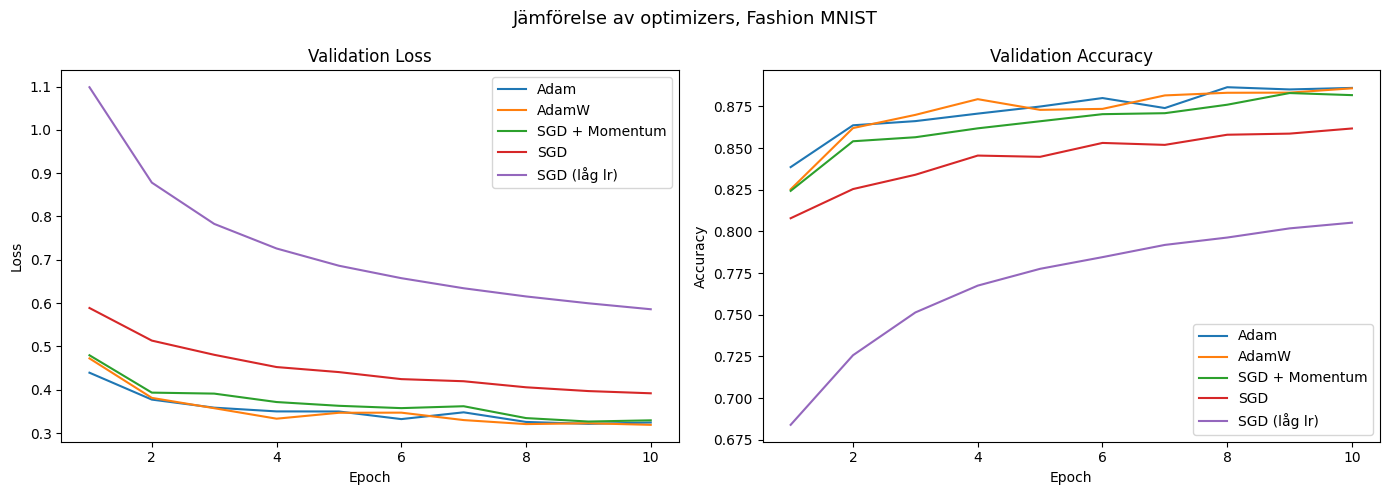

In [21]:
# Träningskurvor för alla optimisers

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['loss']) + 1)

# Loss
ax1.plot(epochs, history.history['val_loss'], label='Adam')
ax1.plot(epochs, history_adamw.history['val_loss'], label='AdamW')
ax1.plot(epochs, history_sgd_m.history['val_loss'], label='SGD + Momentum')
ax1.plot(epochs, history_sgd.history['val_loss'], label='SGD')
ax1.plot(epochs, history_sgd_low.history['val_loss'], label='SGD (låg lr)')
ax1.set_title('Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, history.history['val_accuracy'], label='Adam')
ax2.plot(epochs, history_adamw.history['val_accuracy'], label='AdamW')
ax2.plot(epochs, history_sgd_m.history['val_accuracy'], label='SGD + Momentum')
ax2.plot(epochs, history_sgd.history['val_accuracy'], label='SGD')
ax2.plot(epochs, history_sgd_low.history['val_accuracy'], label='SGD (låg lr)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Jämförelse av optimizers, Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()

### CNN-modell
I denna del undersöker vi hur en Convolutional Neural Network (CNN) presterar jämfört med en traditionell Dense-modell.
CNN är särskilt lämpliga för bilddata eftersom de kan identifiera mönster såsom kanter, former och texturer.
 
Till skillnad från Dense-nätverk:
 
Tar CNN hänsyn till bildens struktur
Kan identifiera lokala mönster
Behöver färre parametrar för bildigenkänning
 

In [22]:
# Modellarkitektur för CNN
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential()
 
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))
 
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
 
    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
 
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
 
    return model
 

In [ ]:
# Komplimering och träning av CNN

cnn_model = build_cnn_model(input_shape=(28, 28, 1), num_classes=10)

cnn_model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
X_train = train_images
y_train = train_labels
X_val = test_images
y_val = test_labels
history_cnn = cnn_model.fit(train_images, train_labels,
epochs=10,
batch_size=32,
validation_data=(test_images, test_labels)
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7980 - loss: 0.5542 - val_accuracy: 0.8414 - val_loss: 0.4292
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8613 - loss: 0.3736 - val_accuracy: 0.8691 - val_loss: 0.3561
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8812 - loss: 0.3208 - val_accuracy: 0.8714 - val_loss: 0.3500
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8942 - loss: 0.2872 - val_accuracy: 0.8884 - val_loss: 0.3073
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9038 - loss: 0.2579 - val_accuracy: 0.8848 - val_loss: 0.3116
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9122 - loss: 0.2346 - val_accuracy: 0.8896 - val_loss: 0.3088
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9204 - loss: 0.2123 - val_accuracy: 0.8910 - val_loss: 0.3052
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9258 - loss: 0

In [25]:
#Resultat för CNN
test_loss, test_acc = cnn_model.evaluate(test_images, test_labels) 
print("CNN Test Accuracy:", test_acc)
print("CNN Test Loss:", test_loss)
 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8938 - loss: 0.3132
CNN Test Accuracy: 0.8938000202178955
CNN Test Loss: 0.3132028877735138


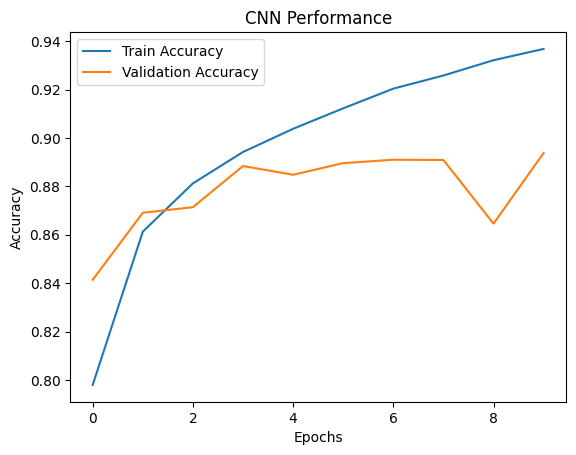

In [26]:
# Visualisering

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
 
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Performance')
plt.legend()
plt.show()

### Slutsats
CNN-modellen uppnådde en test accuracy på cirka 89 %, vilket visar att modellen är bra på att generalisera till ny data.
Under träningen såg vi att accuracy ökade stabilt samtidigt som loss minskade, vilket tyder på att modellen lär sig relevanta mönster.
 
Träningsaccuracy är något högre än validation accuracy, vilket indikerar en viss överanpassning, men skillnaden är relativt liten och därför acceptabel. Att validation accuracy planar ut runt 89 % tyder på att modellen börjar nå sin maximala kapacitet med nuvarande arkitektur och data.
 
Sammantaget visar resultaten att CNN-modellen presterar bra och är bättre lämpad för bildklassificering än en Dense-modell.
 